## Debugging why training was failing

### Case 1:
```
Prompt: 100 + 100=
Model Output: 1.9.1.3<unk><unk><unk><unk><unk><unk><unk><unk>

Prompt: 1 + 1=
Model Output: 1111.9.9.1<unk><unk><unk><unk><unk>

Prompt: 2 * 2=
Model Output: 11116969.9.3<unk><unk><unk>
```

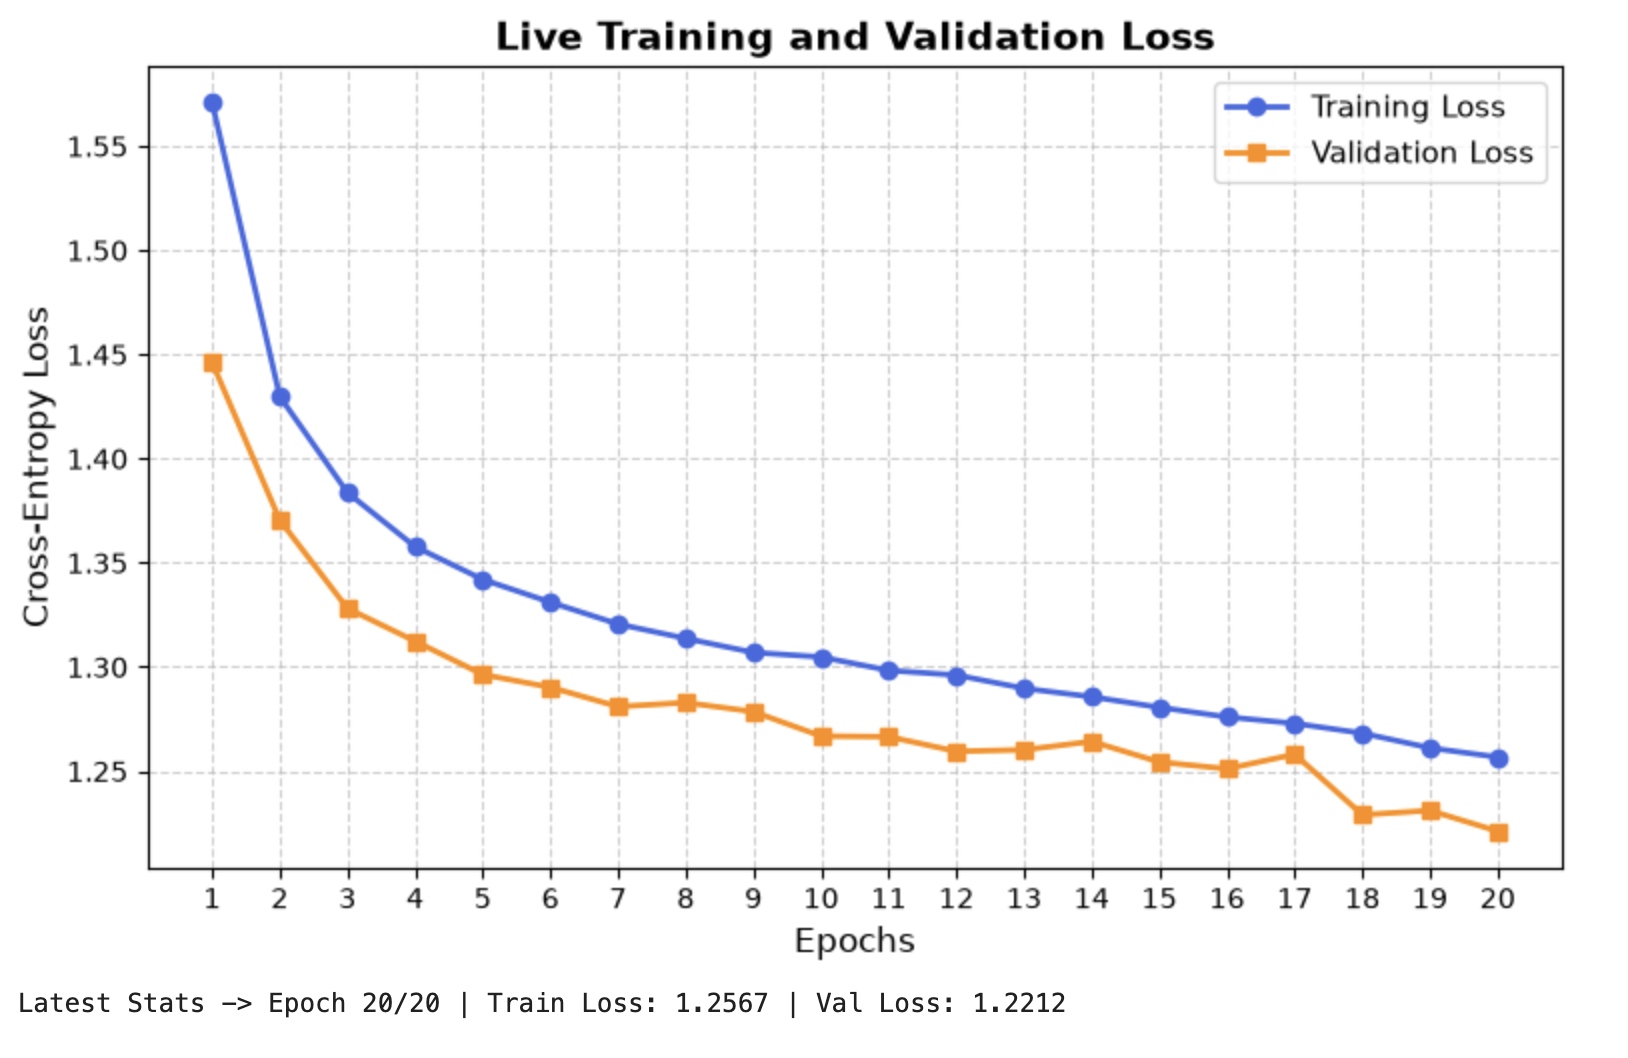

Model was generating gibberish and <unk> tokens even though training/validation loss has been going down.

### Triage 1:
Tried to create dataset of just `2 + 2=4<eos>` to see if it would learn to predict 4. It did memorize to output 4, which means the trainining masking is correct. However, I still get <unk>
```
Prompt: 2 + 2=
Model Output: 4<unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk>
```
It never predicted the eos token and just maxxed out when max_gen_tokens=15 is reached.

### Triage 2:
Found the issue!! I fcked up lol :)
```
test_expr = "2+2=4<eos>"
encoded = tokenizer.encode(test_expr)

print(f"Encoded IDs: {encoded}")
print(f"Index for <eos>: {tokenizer.char_to_int['<eos>']}")
print(f"Index for <unk>: {tokenizer.char_to_int['<unk>']}")
------------
Encoded IDs: [2, 10, 2, 14, 4, 19, 19, 19, 19, 19]
Index for <eos>: 18
Index for <unk>: 19
```

My tokenizer I wrote is char tokenizer, but I am adding `<eos>` in expression, but it actually gets encoded one char at a time, so we never actually train on the token for `<eos>`

Fixing the training code to make sure i handle my data properly... now its no longer predicting `<unk>`!
```
tokenized_sequences = []
for expression, result in raw_data:
    full_str = f"{expression}={result}"
    eos_token_id = tokenizer.char_to_int["<eos>"]
    encoded_ids = tokenizer.encode(full_str)
    encoded_ids.append(eos_token_id)
    tokenized_sequences.append(encoded_ids)
...

ask_transformer("2 + 2")
-----
Top 3 choices:
  Character: '4' | Prob: 100.00%
  Character: '<eos>' | Prob: 0.00%
  Character: '3' | Prob: 0.00%
Top 3 choices:
  Character: '<eos>' | Prob: 100.00%
  Character: '4' | Prob: 0.00%
  Character: '9' | Prob: 0.00%
Prompt: 2 + 2=
Model Output: 4
```

### Case 2:

#### Current config:
- batch_size = 64
- d_model = 64
- max_seq_len = 256
- num_heads = 4
- dataset size = 10,000

Finished new training of 20 epochs. The validation loss continues to stay below training loss, and no overfitting.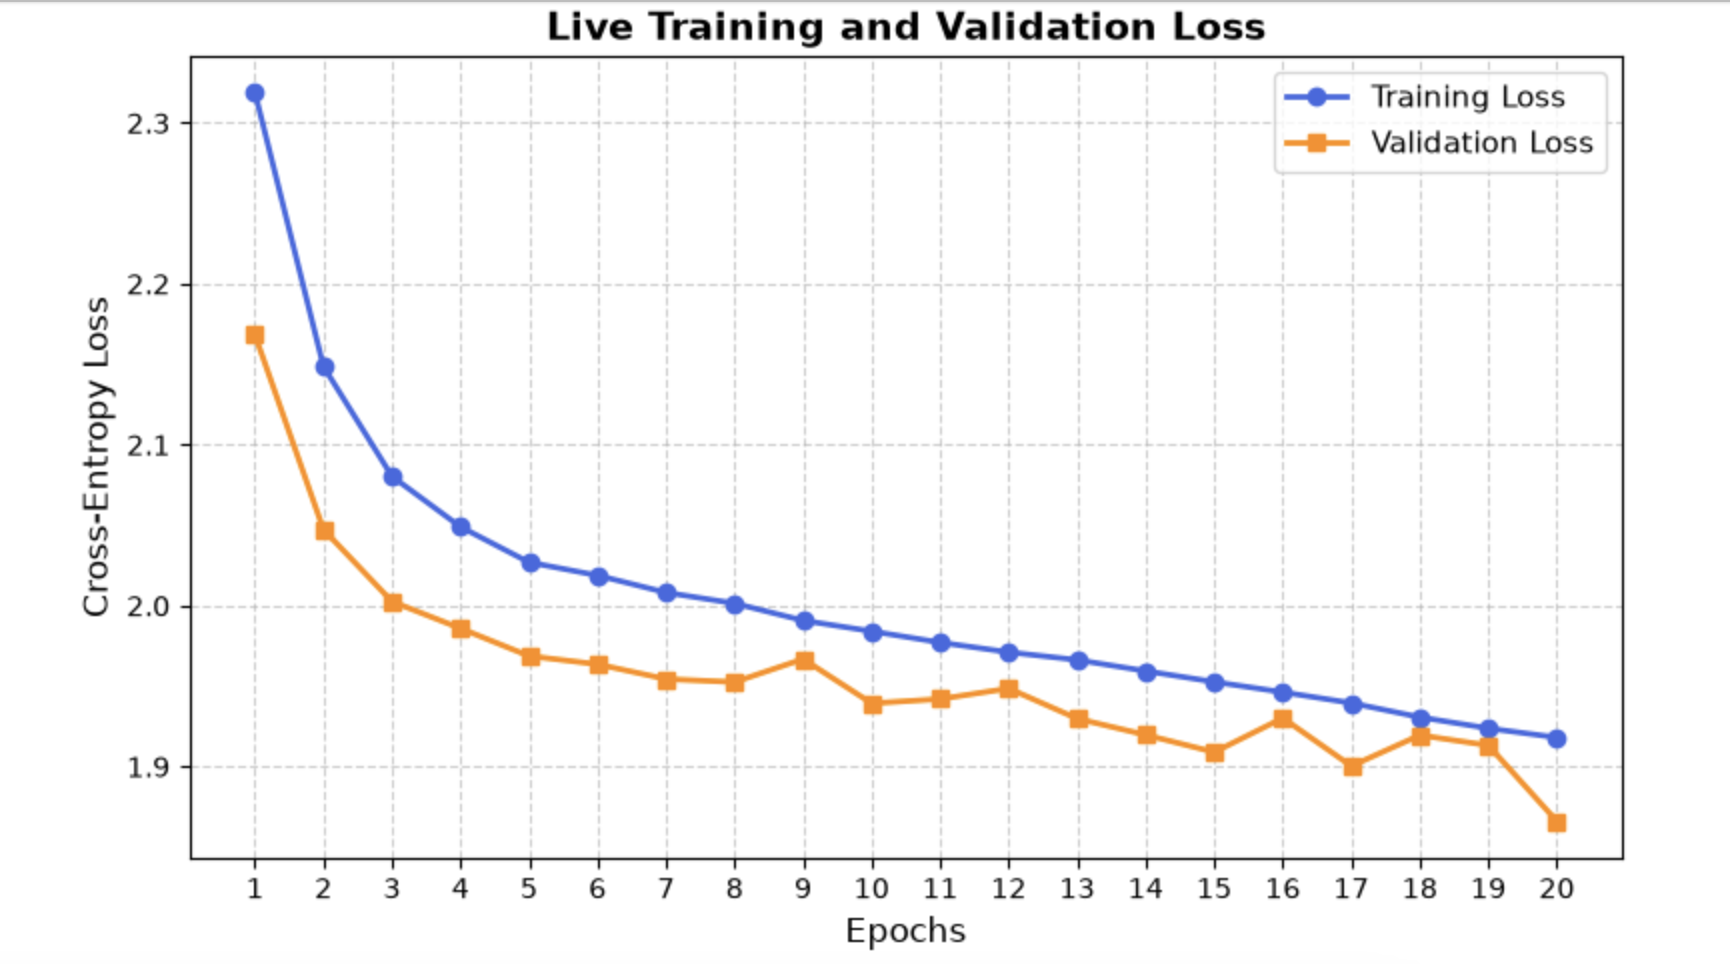

The model now has learned to produce 1, 0, 3, 4 and . since these are common chars in the label. It seems to be stuck here and hitting a wall... probably because the model is too tiny. Next I will try juicing up the model size, and generate more training data.

```
Prompt: 100 + 100=
Model Output: 1.0.3

Prompt: 1 + 1=
Model Output: 10.04.3.3

Prompt: 2 * 2=
Model Output: 10.0

Prompt: 2 - 2=
Model Output: -10.0.0.03

Prompt: 90 + 2 * 5=
Model Output: 1000.04

Prompt: 11 + 12 + 13 * 10=
Model Output: -10.04.33

Prompt: 6 * 6 + 4=
Model Output: 1000.0.33

Prompt: 1 + 2 + 3 + 4 + 5=
Model Output: 10.040.03
```


## Case 3:

Trying bigger model size with 1mm samples dataset
- batch_size = 512
- d_model = 512
- max_seq_len = 256
- num_heads = 8

Only trained for 1 epoch since with 1mm samples, even using T4 GPU it was taking long ass time. After 1 epoch the results still look gibberish... it shouldn't look so ugly since thats 1650 batches and optimization steps. This tells me that perhaps its not about more data or bigger model, something else needs to change.

### Triage 1:
continue training and see what happens...

```
Prompt: 100 + 100=
Model Output: -1.01

Prompt: 1 + 1=
Model Output: 1.1.1.12

Prompt: 2 * 2=
Model Output: -15.4.55.5

Prompt: 2 - 2=
Model Output: -1.0.12.7

Prompt: 90 + 2 * 5=
Model Output: 13.01

Prompt: 11 + 12 + 13 * 10=
Model Output: 29.25

Prompt: 6 * 6 + 4=
Model Output: 41110.0

Prompt: 1 + 2 + 3 + 4 + 5=
Model Output: -2.88
```

at epoch 20 still gibberish, and loss is hitting wall at 1.56. Need to change it up, the model is just not learning


### Triage 2:
Maybe I need to think about how I structure my training data:
- Is the training data to challenging for model to learn?
- Should I start with basics like + and - before teaching * / ? Maybe train on + - first then continue training on * /.
- The hypothesis here would be that models that learned simple + - can extend learned meanings and grok their way to learning how * / work.

I also need to make the batch size smaller.


## Case 4:
Tried to create smaller easier datasets, like chapters in books, and train them one by one...
The dataset with integers, only 2 numbers and plus (+) only was easy for model to learn. After 20 epochs, it reached very low loss.
When I switched to a dataset with integers with 2-3 numbers + only, the loss jumped as expected, since the model has not
seen addition with more than 2 numbers before. However, it did not return to the high at beginning of training, it jumped to
about 50% of the beginning then steadily dropped over the next 80 epoch. 

Problem is that once I added the float dataset, even though it was 2 numbers + only, this caused the model to freak out, and the
loss was very high. After 20 epochs it hit a wall at around 1... 

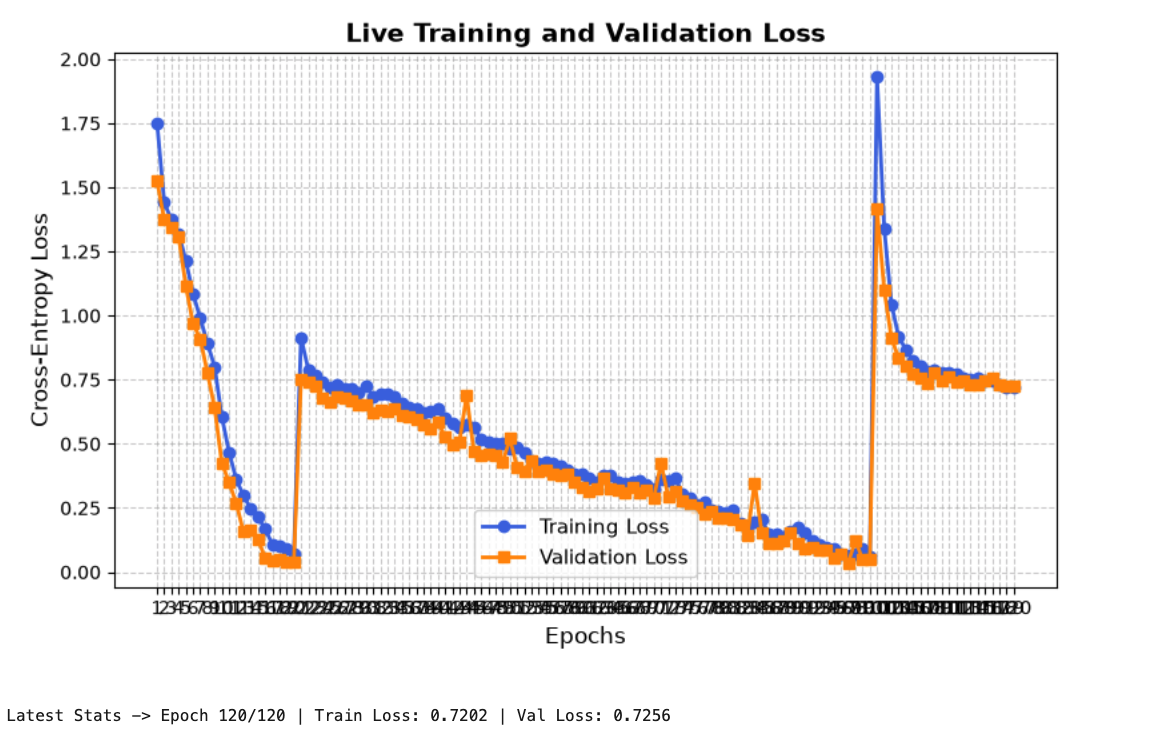

### Triage 1:
Mix in the float number earlier on, so that the model doesn't freak out.

